In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Our modules
from src.data_loader import load_data
from src.cleaning import remove_nulls, normalize_timezone
from src.indicators import add_all_indicators
from src.sentiment import aggregate_daily_sentiment
from src.sentiment import add_sentiment_scores


plt.style.use('seaborn-v0_8')
%matplotlib inline

In [3]:
# Load News Data
news = load_data('../data/raw/news.csv', index_col=0, parse_dates=['date'])
news = normalize_timezone(news, 'date')
news = remove_nulls(news)

print("News shape:", news.shape)
print("Date range:", news['date'].min(), "to", news['date'].max())

# Load Stock Data - NVDA
stock = load_data('../data/raw/stockData/NVDA.csv', 
                  index_col='Date', 
                  parse_dates=True)

print("Stock shape:", stock.shape)
print("Stock date range:", stock.index.min(), "to", stock.index.max())

News shape: (1407328, 5)
Date range: 2009-02-14 00:00:00+00:00 to 2020-06-11 21:12:35+00:00
Stock shape: (3774, 5)
Stock date range: 2009-01-02 00:00:00 to 2023-12-29 00:00:00


In [4]:
# Add all indicators
stock = add_all_indicators(stock)

# Show latest rows
stock[['Close', 'SMA_20', 'RSI', 'BB_Upper', 'BB_Lower', 'Daily_Return']].tail()

,Close,SMA_20,RSI,BB_Upper,BB_Lower,Daily_Return
Date,,,,,,
2023-12-22,48.805527,47.706983,55.352119,50.152737,45.261229,-0.326597
2023-12-26,49.254299,47.759019,57.245971,50.288523,45.229515,0.919511
2023-12-27,49.392231,47.838989,57.837928,50.466927,45.211051,0.280040
2023-12-28,49.497185,47.908266,58.310919,50.632585,45.183947,0.212490
2023-12-29,49.497185,48.046003,58.310919,50.799025,45.292980,0.000000


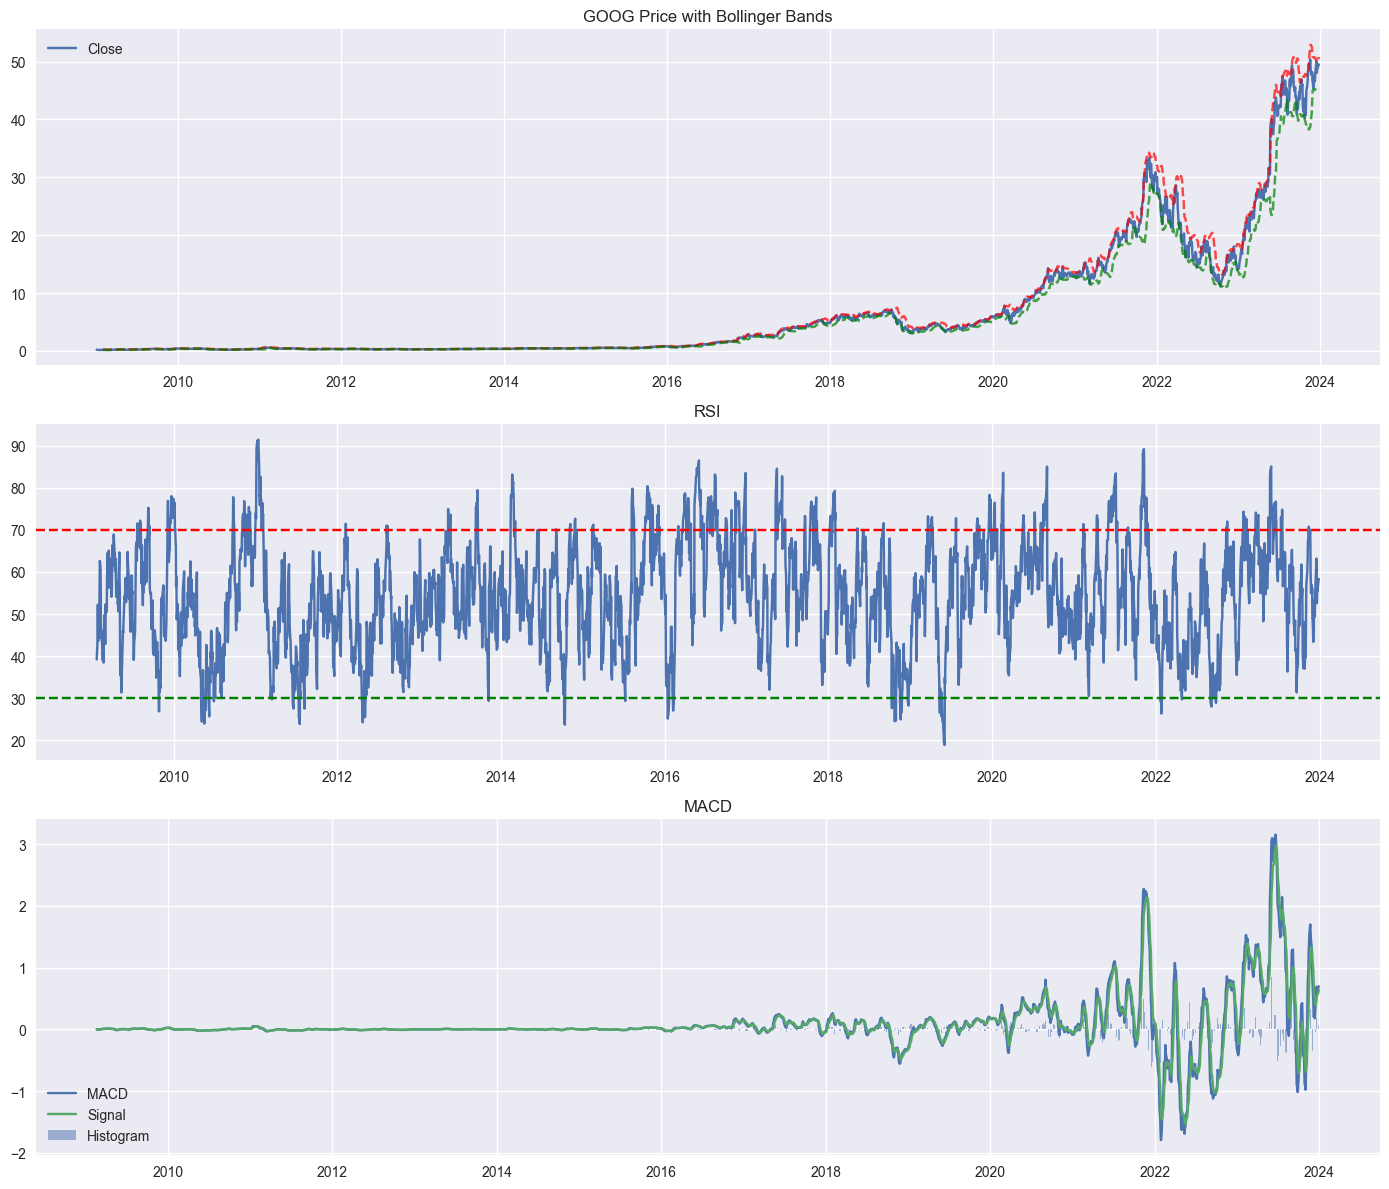

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Price + Bollinger Bands
axes[0].plot(stock.index, stock['Close'], label='Close')
axes[0].plot(stock.index, stock['BB_Upper'], 'r--', alpha=0.7)
axes[0].plot(stock.index, stock['BB_Lower'], 'g--', alpha=0.7)
axes[0].set_title('GOOG Price with Bollinger Bands')
axes[0].legend()

# RSI
axes[1].plot(stock.index, stock['RSI'])
axes[1].axhline(70, color='r', linestyle='--')
axes[1].axhline(30, color='g', linestyle='--')
axes[1].set_title('RSI')

# MACD
axes[2].plot(stock.index, stock['MACD'], label='MACD')
axes[2].plot(stock.index, stock['Signal'], label='Signal')
axes[2].bar(stock.index, stock['Histogram'], label='Histogram', alpha=0.5)
axes[2].set_title('MACD')
axes[2].legend()

plt.tight_layout()
plt.show()

In [6]:
# Get daily sentiment for NVDA
daily_sentiment = aggregate_daily_sentiment(news, 'NVDA')

print("Daily sentiment shape:", daily_sentiment.shape)
daily_sentiment.head()

Processing 3146 articles for NVDA...
why cant i see this?
Applying VADER to 3146 headlines...
getting sentiment for: Shares of several technology companies are trading higher on continued volatility despite market weakness. The sector sold off recently as other sectors gained amid US economic reopening and appears to be rebounding.
scores: {'neg': 0.0, 'neu': 0.803, 'pos': 0.197, 'compound': 0.7296}
getting sentiment for: Afternoon Market Stats in 5 Minutes
scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
getting sentiment for: Morning Market Stats in 5 Minutes
scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
getting sentiment for: Shares of several technology companies are trading higher despite market weakness. The sector recently experienced some welling and appears to be rebounding following dip.
scores: {'neg': 0.0, 'neu': 0.746, 'pos': 0.254, 'compound': 0.7296}
getting sentiment for: Afternoon Market Stats in 5 Minutes
scores: {'neg': 0.0, 'neu': 1.0, '

,date,avg_sentiment,pos,neg,neu,article_count,sentiment_category
0,2011-03-03,-0.5719,0.00000,0.5520,0.44800,1,Negative
1,2011-03-07,-0.2903,0.00000,0.2025,0.79750,2,Negative
2,2011-03-08,0.0234,0.12425,0.0550,0.82075,4,Neutral
3,2011-03-09,0.0000,0.00000,0.0000,1.00000,3,Neutral
4,2011-03-10,0.2023,0.16700,0.0000,0.83300,2,Positive


In [7]:
nvda_news = news[news['stock'] == 'NVDA'].copy()
print("Rows for NVDA:", len(nvda_news))
print("Null headlines:", nvda_news['headline'].isna().sum())
print(nvda_news['headline'].head(10))

Rows for NVDA: 3146
Null headlines: 0
929039    Shares of several technology companies are tra...
929040                  Afternoon Market Stats in 5 Minutes
929041                    Morning Market Stats in 5 Minutes
929042    Shares of several technology companies are tra...
929043                  Afternoon Market Stats in 5 Minutes
929044    Shares of some technology companies are tradin...
929045                    Morning Market Stats in 5 Minutes
929046    Why BofA Recommends Buying GPU Plays AMD and N...
929047    Cramer Weighs In On Ciena, Harley-Davidson And...
929048    Semiconductor Industry to Lobby for Billions t...
Name: headline, dtype: object


In [10]:
# === Prepare Stock Data ===
stock_daily = stock[['Daily_Return']].copy()
stock_daily = stock_daily.reset_index()

# Make sure date column is in the same format (date only)
stock_daily['date'] = pd.to_datetime(stock_daily['Date']).dt.date

print("Stock days:", len(stock_daily))
print("Sentiment days:", len(daily_sentiment))

# === Merge Sentiment + Stock Returns ===
merged = pd.merge(
    daily_sentiment,
    stock_daily,
    on='date',
    how='inner'          # Only keep days where we have BOTH news and stock data
)

print("✅ Merged shape:", merged.shape)
print("Date range:", merged['date'].min(), "to", merged['date'].max())

merged.head()

Stock days: 3774
Sentiment days: 1197
✅ Merged shape: (1125, 9)
Date range: 2011-03-03 to 2020-06-10


,date,avg_sentiment,pos,neg,neu,article_count,sentiment_category,Date,Daily_Return
0,2011-03-03,-0.5719,0.00000,0.5520,0.44800,1,Negative,2011-03-03,0.578321
1,2011-03-07,-0.2903,0.00000,0.2025,0.79750,2,Negative,2011-03-07,-1.396890
2,2011-03-08,0.0234,0.12425,0.0550,0.82075,4,Neutral,2011-03-08,-4.494412
3,2011-03-09,0.0000,0.00000,0.0000,1.00000,3,Neutral,2011-03-09,-2.097166
4,2011-03-10,0.2023,0.16700,0.0000,0.83300,2,Positive,2011-03-10,-6.374086


=== Average Daily Return by Sentiment Category ===

                    Daily_Return  num_days
sentiment_category                        
Negative                 -1.3525       178
Neutral                   0.1709       411
Positive                  0.9200       536


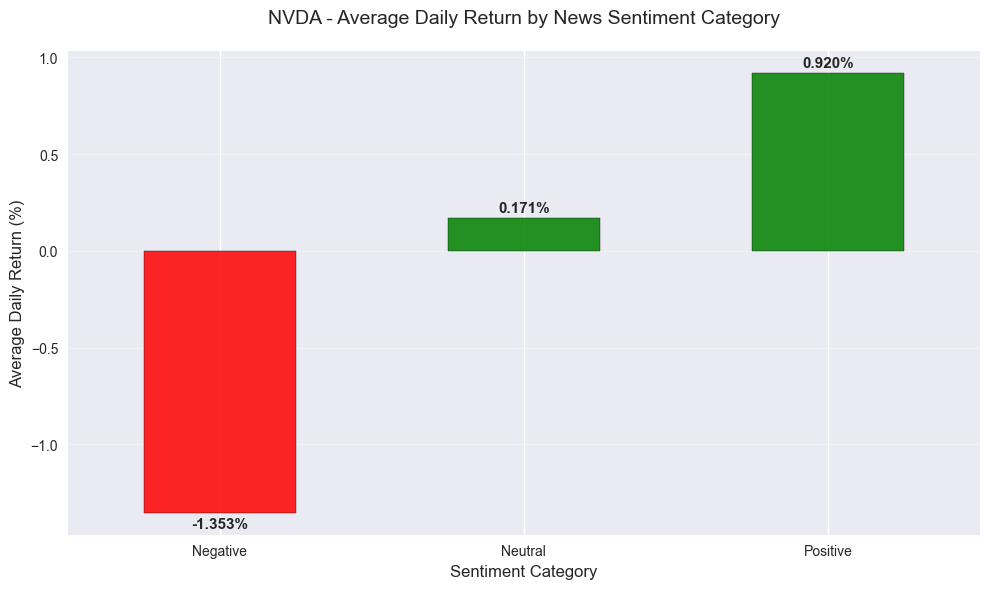

In [11]:
# Average Daily Return by Sentiment
avg_return = merged.groupby('sentiment_category')['Daily_Return'].mean().round(4)
count_per_category = merged.groupby('sentiment_category').size()

print("=== Average Daily Return by Sentiment Category ===\n")
result = pd.concat([avg_return, count_per_category.rename('num_days')], axis=1)
print(result)

# === Bar Chart ===
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in avg_return]

bars = avg_return.plot(kind='bar', color=colors, alpha=0.85, edgecolor='black')

plt.title('NVDA - Average Daily Return by News Sentiment Category', fontsize=14, pad=20)
plt.ylabel('Average Daily Return (%)', fontsize=12)
plt.xlabel('Sentiment Category', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(avg_return):
    plt.text(i, v + (0.03 if v >= 0 else -0.08), 
             f"{v:.3f}%", 
             ha='center', 
             fontsize=11, 
             fontweight='bold')

plt.tight_layout()
plt.show()

Correlation between Average Sentiment Score and Daily Return: 0.2148


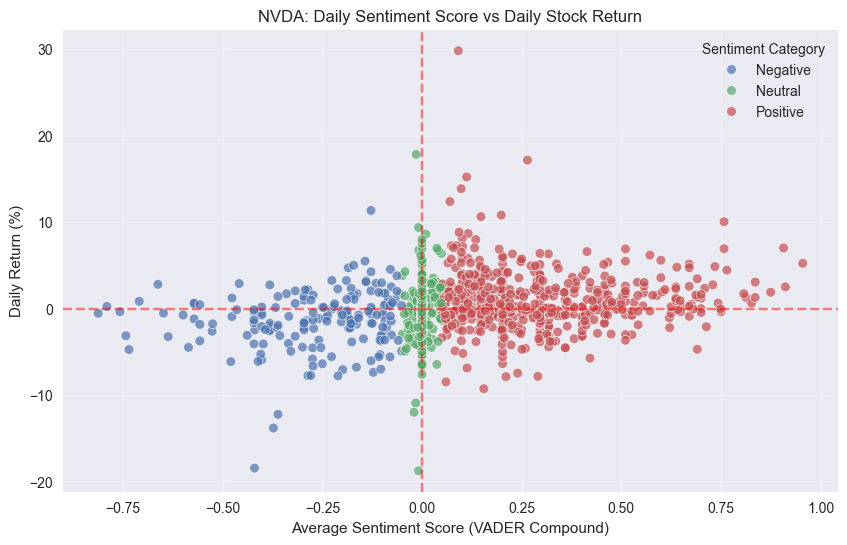

In [12]:
# Correlation
correlation = merged['avg_sentiment'].corr(merged['Daily_Return'])
print(f"Correlation between Average Sentiment Score and Daily Return: {correlation:.4f}")

# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged, x='avg_sentiment', y='Daily_Return', alpha=0.7, hue='sentiment_category')
plt.title('NVDA: Daily Sentiment Score vs Daily Stock Return')
plt.xlabel('Average Sentiment Score (VADER Compound)')
plt.ylabel('Daily Return (%)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.legend(title='Sentiment Category')
plt.show()

In [ ]:
print("=== Summary Statistics NVDA ===")
print(f"Total trading days with news: {len(merged)}")
print(f"Positive sentiment days : {count_per_category.get('Positive', 0)}")
print(f"Neutral sentiment days  : {count_per_category.get('Neutral', 0)}")
print(f"Negative sentiment days : {count_per_category.get('Negative', 0)}")
print(f"Best average return     : {avg_return.max():.3f}% on {avg_return.idxmax()}")
print(f"Worst average return    : {avg_return.min():.3f}% on {avg_return.idxmin()}")

=== Summary Statistics ===
Total trading days with news: 1125
Positive sentiment days : 536
Neutral sentiment days  : 411
Negative sentiment days : 178
Best average return     : 0.920% on Positive
Worst average return    : -1.353% on Negative
